# GeoPandas Challenge 


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

In [11]:

# Reload fresh without overriding CRS
tracts = gpd.read_file('NRI_Shapefile_CensusTracts.shp')
tracts = tracts.replace(-9999, np.nan)


In [15]:

# Filter Colorado
california = tracts[tracts["STATE"].str.lower() == "california"].copy()


In [16]:
# Create custom variable
california["FIRE_QUAKE_INDEX"] = (california["WFIR_RISKS"] + california["ERQK_RISKS"]) / 2

In [ ]:
#print(california["FIRE_QUAKE_INDEX"].describe())

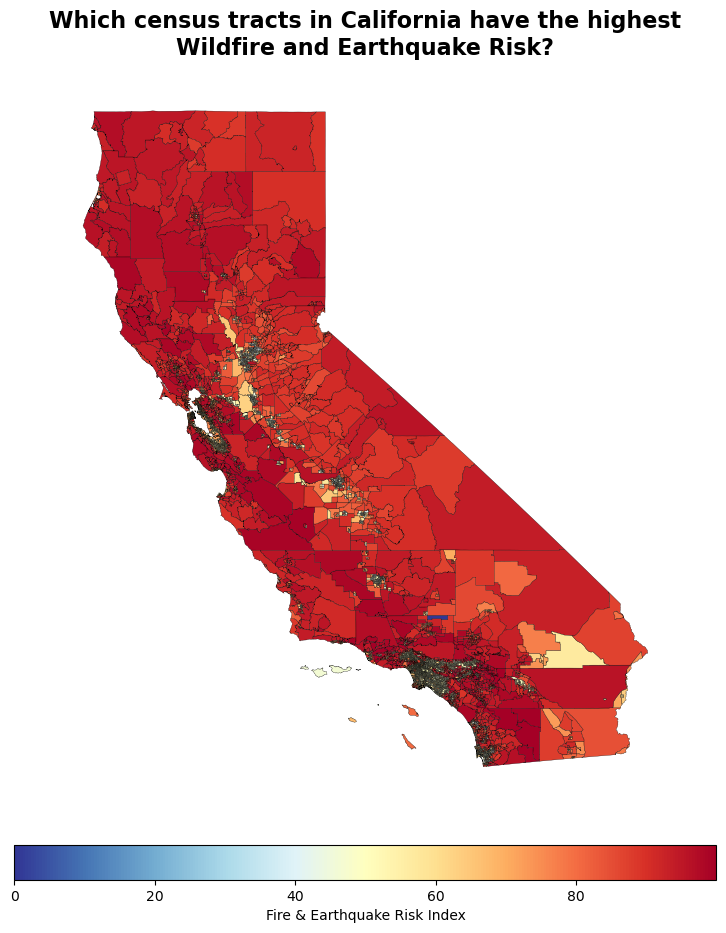

In [17]:
# Plot
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

california.plot(
    column="FIRE_QUAKE_INDEX",
    ax=ax,
    legend=True,
    linewidth=0.2,
    edgecolor="black",
    cmap="RdYlBu_r",
    legend_kwds={
        "label": "Fire & Earthquake Risk Index",
        "orientation": "horizontal",
        "shrink": 0.6,
        "pad": 0.05
    },
    missing_kwds={"color": "lightgrey", "label": "No Data"}
)

ax.set_title(
    "Which census tracts in California have the highest\nWildfire and Earthquake Risk?",
    fontsize=16,
    fontweight="bold"
)
ax.set_axis_off()
plt.tight_layout()
plt.show()